<a href="https://colab.research.google.com/github/sebin-droid/predictive-_analytics_lab_exam_2/blob/main/predictive_analytics_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   sepal length (cm)  sepal width (cm)  target
0                5.1               3.5       0
1                4.9               3.0       0
2                4.7               3.2       0
3                4.6               3.1       0
4                5.0               3.6       0

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
target               0
dtype: int64


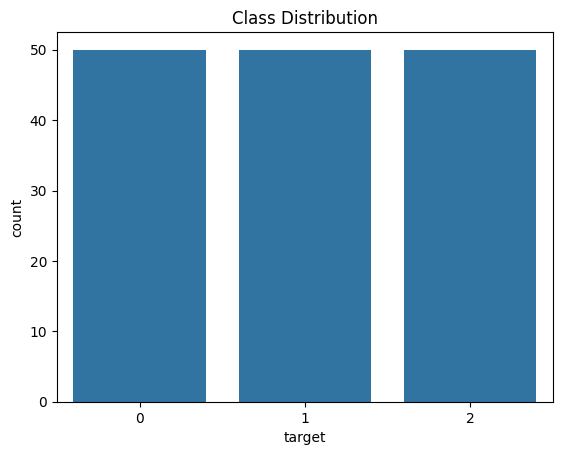

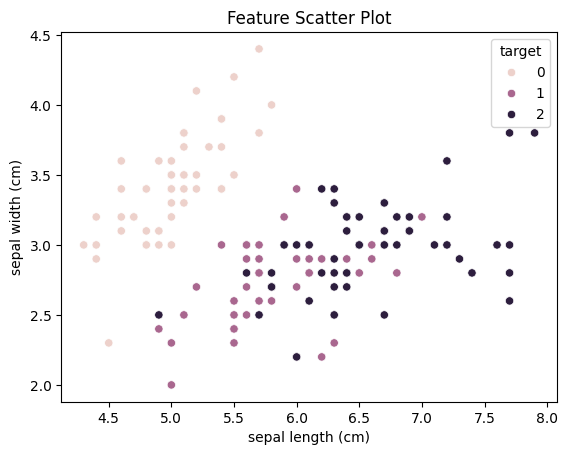

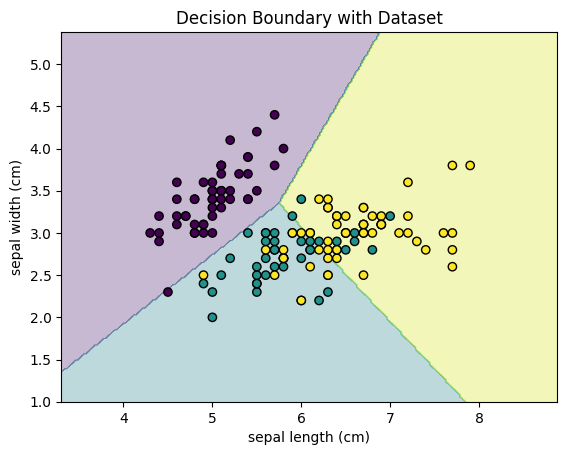


Accuracy: 0.8222222222222222

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.78      0.54      0.64        13
           2       0.65      0.85      0.73        13

    accuracy                           0.82        45
   macro avg       0.81      0.79      0.79        45
weighted avg       0.83      0.82      0.82        45



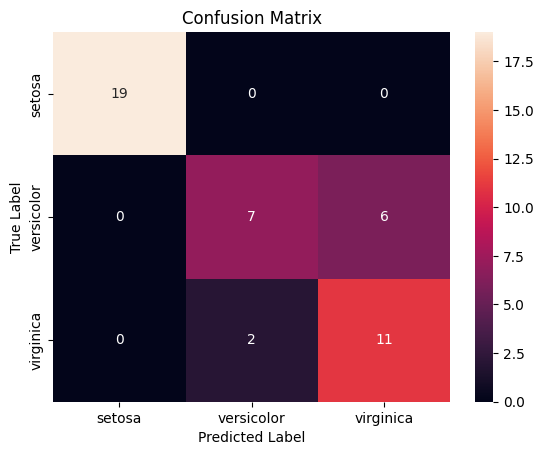

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



iris = load_iris()


X = iris.data[:, :2]
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names[:2])
df['target'] = y



print("First 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


plt.figure()
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()


plt.figure()
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['target'])
plt.title("Feature Scatter Plot")
plt.show()



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)



x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Decision Boundary with Dataset")
plt.show()



y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()